# 经典 Iris 鸢尾花 KNN 分类示例

Iris 数据集是机器学习领域最经典的数据集之一，包含3种鸢尾花（山鸢尾、变色鸢尾、维吉尼亚鸢尾）的4个特征：
- sepal length（花萼长度）
- sepal width（花萼宽度）
- petal length（花瓣长度）
- petal width（花瓣宽度）

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

## 步骤1：加载与探索数据

In [2]:
# 加载数据
# type: ignore
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print(f"数据集大小: {X.shape}")
print(f"类别数量: {len(target_names)}")
print(f"特征名称: {feature_names}")
print(f"类别名称: {target_names}")

# 创建DataFrame便于观察
df = pd.DataFrame(X, columns=feature_names)
df['species'] = [target_names[i] for i in y]
print("\n数据前5行：")
print(df.head())

print("\n各类别样本数量：")
print(df['species'].value_counts())

数据集大小: (150, 4)
类别数量: 3
特征名称: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
类别名称: ['setosa' 'versicolor' 'virginica']

数据前5行：
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

各类别样本数量：
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 步骤2：数据可视化（特征分布与相关性）

C:\Users\qiaoy\AppData\Local\Temp\ipykernel_21716\4286574870.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='sepal length (cm)', ax=axes[0, 2], palette='Set1')
C:\Users\qiaoy\AppData\Local\Temp\ipykernel_21716\4286574870.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='petal length (cm)', ax=axes[1, 0], palette='Set1')
C:\Users\qiaoy\AppData\Local\Temp\ipykernel_21716\4286574870.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y='petal width (cm)', ax=axe

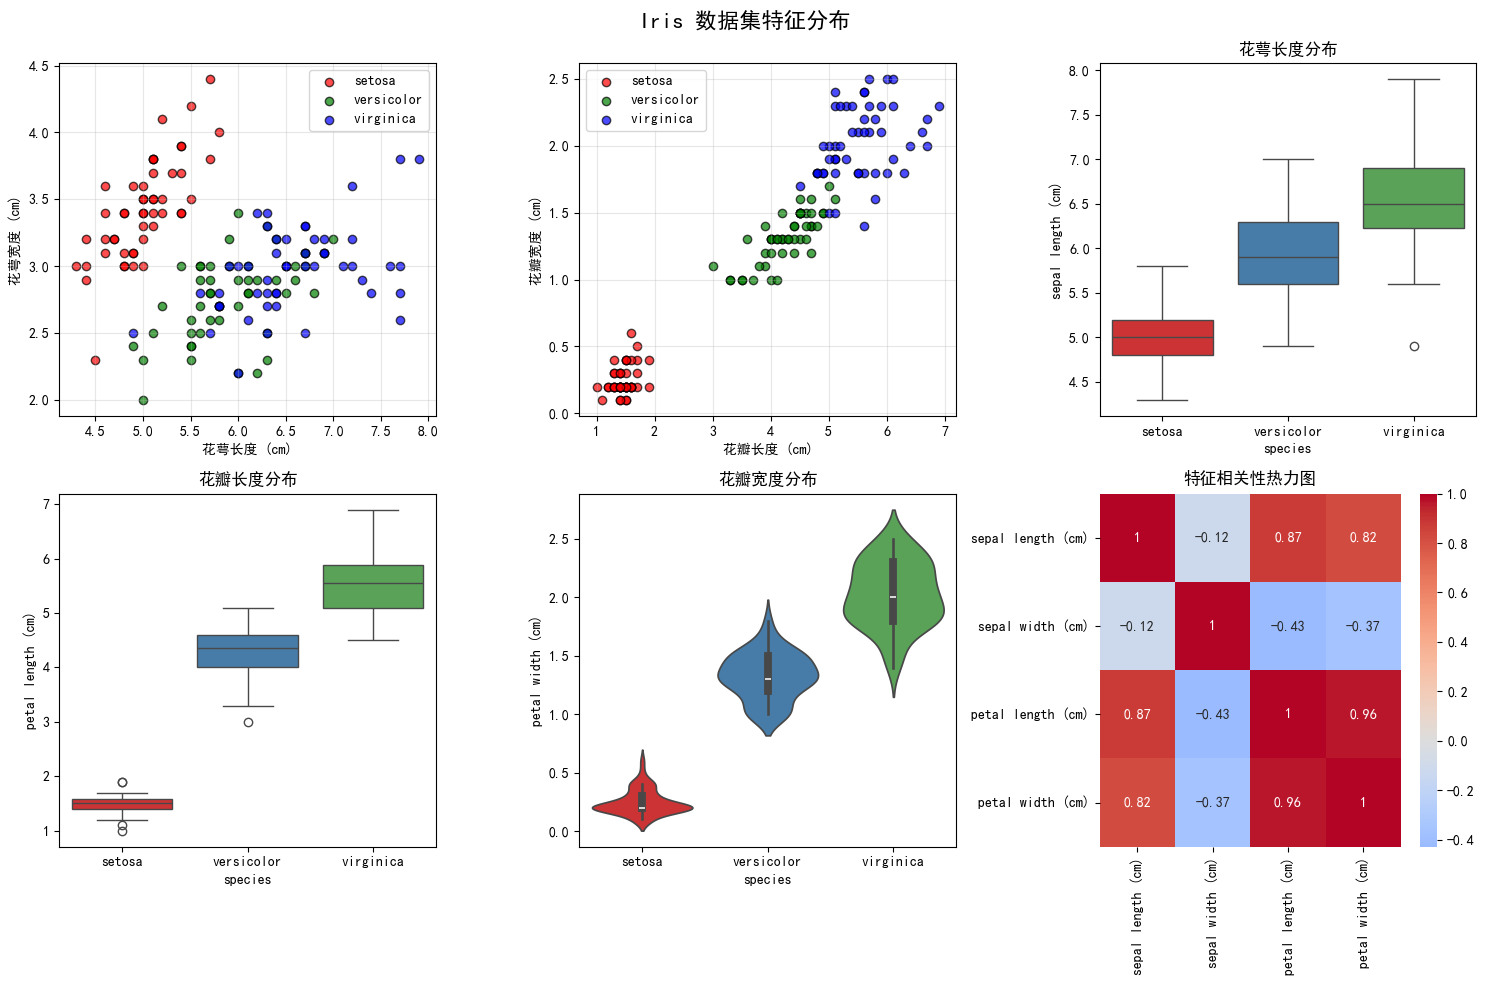

观察：花瓣特征（尤其是花瓣长度）对区分三类鸢尾花非常有效！


In [3]:
# 绘制特征分布散点图矩阵
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Iris 数据集特征分布', fontsize=16)

# 颜色映射
colors = ['red', 'green', 'blue']
color_map = {0: 'red', 1: 'green', 2: 'blue'}

# 子图1: 花萼长 vs 花萼宽
for i, target in enumerate(target_names):
    mask = y == i
    axes[0, 0].scatter(X[mask, 0], X[mask, 1], c=colors[i], label=target, alpha=0.7, edgecolors='k')
axes[0, 0].set_xlabel('花萼长度 (cm)')
axes[0, 0].set_ylabel('花萼宽度 (cm)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 子图2: 花瓣长 vs 花瓣宽
for i, target in enumerate(target_names):
    mask = y == i
    axes[0, 1].scatter(X[mask, 2], X[mask, 3], c=colors[i], label=target, alpha=0.7, edgecolors='k')
axes[0, 1].set_xlabel('花瓣长度 (cm)')
axes[0, 1].set_ylabel('花瓣宽度 (cm)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 子图3: 箱线图 - 花萼长度
sns.boxplot(data=df, x='species', y='sepal length (cm)', ax=axes[0, 2], palette='Set1')
axes[0, 2].set_title('花萼长度分布')

# 子图4: 箱线图 - 花瓣长度
sns.boxplot(data=df, x='species', y='petal length (cm)', ax=axes[1, 0], palette='Set1')
axes[1, 0].set_title('花瓣长度分布')

# 子图5: 小提琴图 - 花瓣宽度
sns.violinplot(data=df, x='species', y='petal width (cm)', ax=axes[1, 1], palette='Set1')
axes[1, 1].set_title('花瓣宽度分布')

# 子图6: 热力图 - 特征相关性
corr_matrix = df.iloc[:, :-1].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1, 2])
axes[1, 2].set_title('特征相关性热力图')

plt.tight_layout()
plt.show()

print("观察：花瓣特征（尤其是花瓣长度）对区分三类鸢尾花非常有效！")

## 步骤3：划分训练集与测试集

In [4]:
# 划分数据集（80%训练，20%测试）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"训练集大小: {X_train.shape}")
print(f"测试集大小: {X_test.shape}")

# KNN对特征尺度敏感，进行标准化（虽然Iris数据尺度相近，但这是个好习惯）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n特征标准化完成（均值为0，方差为1）")

训练集大小: (120, 4)
测试集大小: (30, 4)

特征标准化完成（均值为0，方差为1）


In [5]:
# type: ignore
from collections import Counter


class KNN:
    def __init__(self, k=3):
        self.k = k
    
    def fit(self, X, y):
        """惰性学习：仅存储训练数据"""
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self
    
    def predict(self, X):
        """预测多个样本"""
        X = np.array(X)
        return np.array([self._predict_one(x) for x in X])
    
    def _predict_one(self, x):
        """预测单个样本"""
        # 计算到所有训练样本的欧氏距离
        distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
        
        # 获取距离最近的k个邻居的索引
        k_indices = np.argsort(distances)[:self.k]
        
        # 获取邻居的标签
        k_nearest_labels = self.y_train[k_indices]
        
        # 投票（分类）或平均（回归）
        if self.y_train.dtype.kind in 'iufb':  # 整数/浮点/布尔，判断为分类
            return Counter(k_nearest_labels).most_common(1)[0][0]
        else:
            return np.mean(k_nearest_labels)
    
    def predict_proba(self, X):
        """返回各类别的概率（分类任务用）"""
        X = np.array(X)
        probs = []
        for x in X:
            distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
            k_indices = np.argsort(distances)[:self.k]
            k_labels = self.y_train[k_indices]
            
            # 统计频率
            counter = Counter(k_labels)
            total = sum(counter.values())
            prob_dict = {cls: cnt/total for cls, cnt in counter.items()}
            probs.append(prob_dict)
        return probs

knn = KNN(k=5)
knn.fit(X_train_scaled, y_train)

# 预测
predictions = knn.predict(X_test_scaled)
accuracy = np.mean(predictions == y_test)

print(f"手动KNN准确率: {accuracy:.4f}")
print(f"前3个预测: {predictions[:3]}")
print(f"真实标签:  {y_test[:3]}")

# 查看预测概率
proba = knn.predict_proba(X_test_scaled[:1])
print(f"\n第一个样本的预测概率: {proba[0]}")



手动KNN准确率: 0.9333
前3个预测: [0 2 1]
真实标签:  [0 2 1]

第一个样本的预测概率: {np.int64(0): 1.0}


## 步骤4：KNN 模型训练与预测

In [6]:
# 创建KNN分类器，K=3
#type: ignore
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')

# 训练模型
knn.fit(X_train_scaled, y_train)

# 预测
y_pred = knn.predict(X_test_scaled)
y_pred_proba = knn.predict_proba(X_test_scaled)

print("预测结果：")
print(f"真实标签: {y_test}")
print(f"预测标签: {y_pred}")
print(f"预测概率（前3个样本）：\n{y_pred_proba[:3].round(4)}")

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"\n测试集准确率: {accuracy:.4f} ({accuracy*100:.2f}%)")

预测结果：
真实标签: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]
预测标签: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 1 1 0 2 0]
预测概率（前3个样本）：
[[1.     0.     0.    ]
 [0.     0.3333 0.6667]
 [0.     1.     0.    ]]

测试集准确率: 0.9333 (93.33%)


## 步骤5：模型评估（混淆矩阵与详细报告）

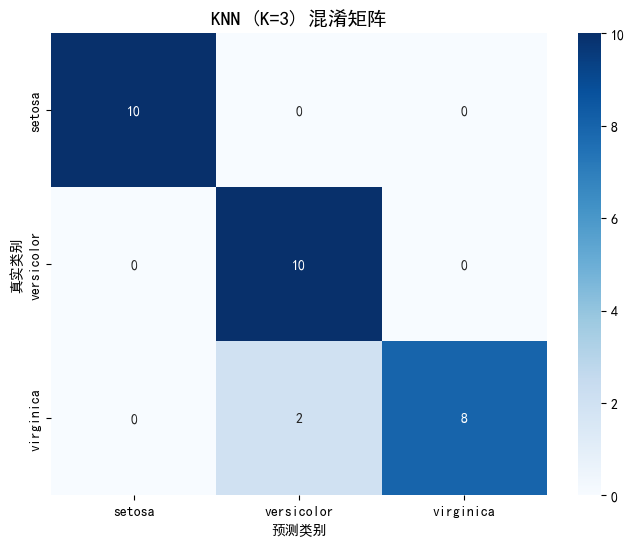

分类报告：
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30


预测错误的样本索引: [19 23]
真实类别: [2 2]
预测类别: [1 1]


In [7]:
# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('预测类别')
plt.ylabel('真实类别')
plt.title('KNN (K=3) 混淆矩阵', fontsize=14)
plt.show()

# 详细分类报告
print("分类报告：")
print(classification_report(y_test, y_pred, target_names=target_names))

# 找出预测错误的样本
errors = y_test != y_pred
if errors.any():
    print(f"\n预测错误的样本索引: {np.where(errors)[0]}")
    print(f"真实类别: {y_test[errors]}")
    print(f"预测类别: {y_pred[errors]}")
else:
    print("\n完美预测！所有测试样本均分类正确。")

## 步骤6：选择最优 K 值（交叉验证）

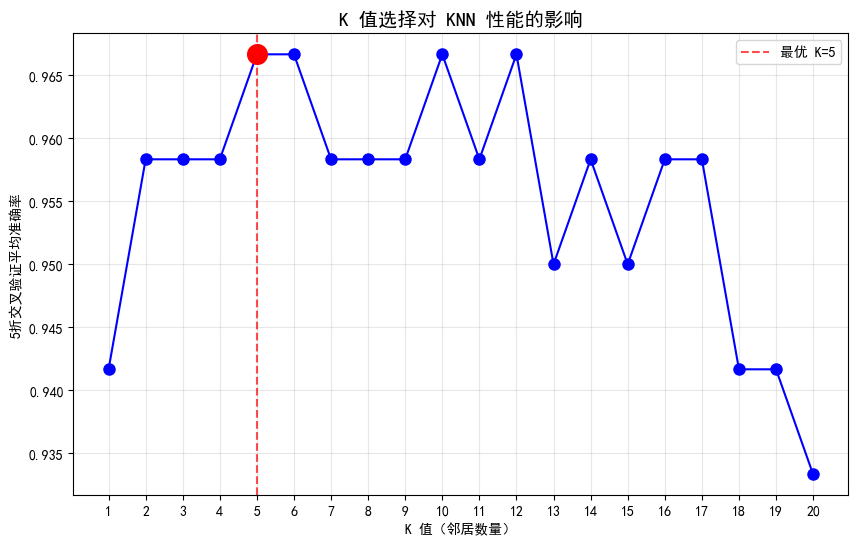

最优 K 值: 5，交叉验证准确率: 0.9667
使用最优K=5的测试集准确率: 0.9333


In [8]:
# 测试不同的K值（1-20）
k_range = range(1, 21)
cv_scores = []

for k in k_range:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    # 5折交叉验证
    scores = cross_val_score(knn_cv, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# 绘制K值与准确率关系
plt.figure(figsize=(10, 6))
plt.plot(k_range, cv_scores, marker='o', linestyle='-', color='b', markersize=8)
plt.xlabel('K 值（邻居数量）')
plt.ylabel('5折交叉验证平均准确率')
plt.title('K 值选择对 KNN 性能的影响', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_range)

# 标注最优K值
best_k = k_range[np.argmax(cv_scores)]
best_score = max(cv_scores)
plt.axvline(x=best_k, color='r', linestyle='--', alpha=0.7, label=f'最优 K={best_k}')
plt.scatter(best_k, best_score, color='red', s=200, zorder=5)
plt.legend()
plt.show()

print(f"最优 K 值: {best_k}，交叉验证准确率: {best_score:.4f}")

# 使用最优K值重新训练
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)
final_accuracy = best_knn.score(X_test_scaled, y_test)
print(f"使用最优K={best_k}的测试集准确率: {final_accuracy:.4f}")

## 步骤7：决策边界可视化（使用两个主要特征）

为了可视化，我们只使用花瓣长度和花瓣宽度两个最具区分性的特征

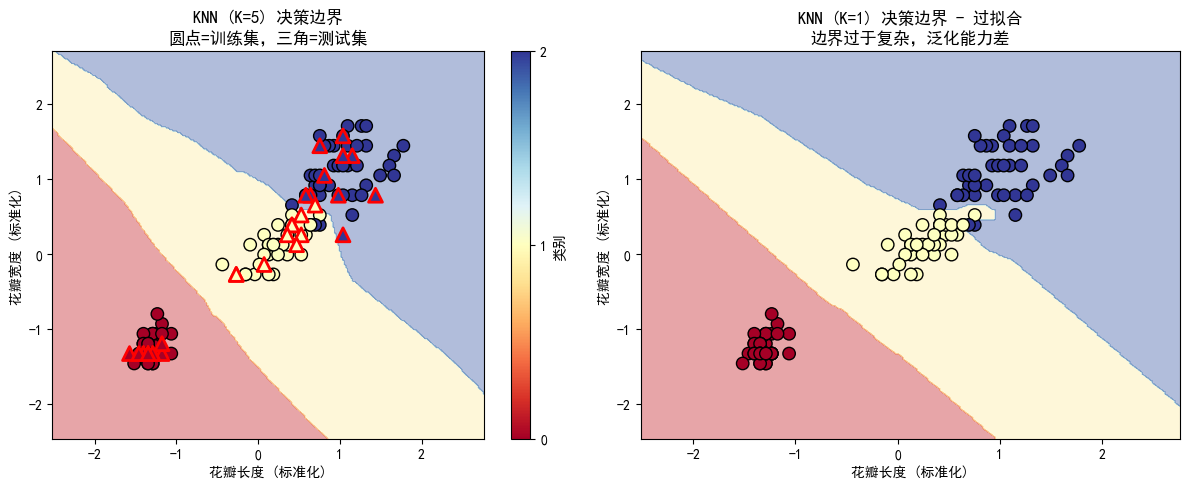

观察：K=1 时决策边界非常复杂（过拟合），K=5 时边界更平滑（泛化更好）


In [9]:
# 只使用花瓣长度和花瓣宽度（第2、3列）
X_2d = X[:, [2, 3]]

# 重新划分
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.2, random_state=42, stratify=y
)

# 标准化
scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

# 创建网格用于绘制决策边界
h = 0.02  # 网格步长
x_min, x_max = X_train_2d_scaled[:, 0].min() - 1, X_train_2d_scaled[:, 0].max() + 1
y_min, y_max = X_train_2d_scaled[:, 1].min() - 1, X_train_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# 训练2D KNN模型
knn_2d = KNeighborsClassifier(n_neighbors=5)
knn_2d.fit(X_train_2d_scaled, y_train_2d)

# 预测整个网格
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 绘制
plt.figure(figsize=(12, 5))

# 子图1: K=5 决策边界
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)
scatter = plt.scatter(X_train_2d_scaled[:, 0], X_train_2d_scaled[:, 1], 
                     c=y_train_2d, cmap=plt.cm.RdYlBu, edgecolors='black', s=80)
plt.scatter(X_test_2d_scaled[:, 0], X_test_2d_scaled[:, 1], 
           c=y_test_2d, cmap=plt.cm.RdYlBu, edgecolors='red', marker='^', s=100, linewidth=2)
plt.xlabel('花瓣长度 (标准化)')
plt.ylabel('花瓣宽度 (标准化)')
plt.title('KNN (K=5) 决策边界\n圆点=训练集，三角=测试集')
plt.colorbar(scatter, ticks=[0, 1, 2], label='类别')

# 子图2: K=1 决策边界（过拟合）
knn_overfit = KNeighborsClassifier(n_neighbors=1)
knn_overfit.fit(X_train_2d_scaled, y_train_2d)
Z_overfit = knn_overfit.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z_overfit, alpha=0.4, cmap=plt.cm.RdYlBu)
plt.scatter(X_train_2d_scaled[:, 0], X_train_2d_scaled[:, 1], 
           c=y_train_2d, cmap=plt.cm.RdYlBu, edgecolors='black', s=80)
plt.xlabel('花瓣长度 (标准化)')
plt.ylabel('花瓣宽度 (标准化)')
plt.title('KNN (K=1) 决策边界 - 过拟合\n边界过于复杂，泛化能力差')

plt.tight_layout()
plt.show()

print("观察：K=1 时决策边界非常复杂（过拟合），K=5 时边界更平滑（泛化更好）")

## 总结

### KNN 在 Iris 分类中的关键点：

1. **特征重要性**：花瓣特征（长度、宽度）比花萼特征更具区分性，尤其是区分 setosa 与其他两类

2. **K值选择**：
   - K太小（如K=1）：模型复杂，容易过拟合，对噪声敏感
   - K太大：模型过于简单，可能欠拟合，边界模糊
   - 通过交叉验证选择最优K（本例中K=5-9效果较好）

3. **距离度量**：
   - 欧氏距离（Euclidean）：最常用，适合连续特征
   - 曼哈顿距离（Manhattan）：对异常值更鲁棒
   - 闵可夫斯基距离（Minkowski）：通用形式

4. **特征缩放**：KNN 基于距离计算，必须进行标准化/归一化，避免量纲大的特征主导距离

5. **算法复杂度**：
   - 训练复杂度：O(1)（惰性学习，仅存储数据）
   - 预测复杂度：O(N)（需计算与所有训练样本的距离）

### 与协同过滤的对比：

| 特性 | Iris 分类 (KNN) | 推荐系统 (CF) |
|------|----------------|---------------|
| **输入** | 特征向量 (4维) | 用户-物品评分矩阵 |
| **输出** | 类别标签 | 预测评分/推荐列表 |
| **相似度** | 样本间距离 | 用户/物品间相似度 |
| **K的含义** | 近邻样本数 | 相似用户/物品数 |
| **预测方式** | 多数投票/平均 | 加权评分预测 |

# KNN 在推荐系统中的应用详解

## 背景知识

KNN（K-Nearest Neighbors，K近邻算法）是**协同过滤推荐系统**的核心基础算法，主要用于：

1. **基于用户的协同过滤（User-Based CF）**：找到与目标用户兴趣相似的K个用户，推荐这些用户喜欢的物品
2. **基于物品的协同过滤（Item-Based CF）**：找到与目标物品相似的K个物品，进行相关推荐

KNN 通过计算用户或物品之间的相似度（余弦相似度、皮尔逊相关系数等），找出最相似的邻居，进而生成推荐。

In [10]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# 设置显示选项
np.random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

## 步骤1：构建示例评分数据

创建一个用户-物品评分矩阵，模拟5个用户对6部电影的评分（1-5分，0表示未观看）

In [11]:
# 创建用户-物品评分矩阵
data = {
    '用户A': [5, 3, 4, 0, 2, 0],
    '用户B': [4, 0, 5, 3, 0, 4],
    '用户C': [0, 2, 0, 5, 4, 3],
    '用户D': [3, 4, 3, 0, 0, 2],
    '用户E': [0, 0, 4, 4, 5, 0]
}

movies = ['星际穿越', '泰坦尼克号', '盗梦空间', '肖申克的救赎', '阿甘正传', '教父']

df = pd.DataFrame(data, index=movies).T
print("用户-电影评分矩阵（0表示未观看）：")
print(df)

用户-电影评分矩阵（0表示未观看）：
     星际穿越  泰坦尼克号  盗梦空间  肖申克的救赎  阿甘正传  教父
用户A     5      3     4       0     2   0
用户B     4      0     5       3     0   4
用户C     0      2     0       5     4   3
用户D     3      4     3       0     0   2
用户E     0      0     4       4     5   0


## 步骤2：基于用户的协同过滤（User-Based CF）

使用 KNN 找到与目标用户最相似的K个用户，通过他们的评分预测目标用户对未观看电影的喜好

In [12]:
def user_based_recommendation(target_user, k=2):
    """
    基于用户的协同过滤推荐
    target_user: 目标用户
    k: 近邻数量
    """
    # 获取目标用户的评分
    target_ratings = df.loc[target_user].values.reshape(1, -1)
    
    # 计算与其他用户的余弦相似度
    similarities = {}
    for user in df.index:
        if user != target_user:
            user_ratings = df.loc[user].values.reshape(1, -1)
            # 只考虑两者都评过分的电影
            mask = (target_ratings[0] > 0) & (user_ratings[0] > 0)
            if mask.sum() > 0:
                sim = cosine_similarity(
                    target_ratings[0][mask].reshape(1, -1),
                    user_ratings[0][mask].reshape(1, -1)
                )[0][0]
                similarities[user] = sim
    
    # 排序获取Top-K相似用户
    sorted_sim = sorted(similarities.items(), key=lambda x: x[1], reverse=True)
    top_k_users = sorted_sim[:k]
    
    print(f"与用户 {target_user} 最相似的{k}个用户：")
    for user, sim in top_k_users:
        print(f"  {user}: 相似度 = {sim:.4f}")
    
    # 预测未观看电影的评分
    recommendations = {}
    target_unwatched = df.columns[df.loc[target_user] == 0]
    
    for movie in target_unwatched:
        weighted_sum = 0
        sim_sum = 0
        
        for user, sim in top_k_users:
            rating = df.loc[user, movie]
            if rating > 0:  # 该用户看过这部电影
                weighted_sum += sim * rating
                sim_sum += sim
        
        if sim_sum > 0:
            predicted_rating = weighted_sum / sim_sum
            recommendations[movie] = predicted_rating
    
    # 排序推荐
    sorted_rec = sorted(recommendations.items(), key=lambda x: x[1], reverse=True)
    
    print(f"\n为用户 {target_user} 的推荐（预测评分）：")
    for movie, score in sorted_rec:
        print(f"  {movie}: {score:.2f}")
    
    return sorted_rec, top_k_users

# 为用户A生成推荐
recommendations, similar_users = user_based_recommendation('用户A', k=2)

与用户 用户A 最相似的2个用户：
  用户B: 相似度 = 0.9756
  用户D: 相似度 = 0.9459

为用户 用户A 的推荐（预测评分）：
  教父: 3.02
  肖申克的救赎: 3.00


## 步骤3：基于物品的协同过滤（Item-Based CF）

使用 KNN 找到与目标物品最相似的K个物品，常用于"看了又看"的推荐场景

In [13]:
def item_based_recommendation(target_movie, k=2):
    """
    基于物品的协同过滤推荐
    target_movie: 目标电影
    k: 近邻数量
    """
    # 转置数据，以物品为行
    item_matrix = df.T
    
    # 获取目标物品的评分向量
    target_vector = item_matrix.loc[target_movie].values.reshape(1, -1)
    
    # 计算与其他物品的相似度
    similarities = {}
    for movie in item_matrix.index:
        if movie != target_movie:
            movie_vector = item_matrix.loc[movie].values.reshape(1, -1)
            # 只考虑被同一批用户评过分的
            mask = (target_vector[0] > 0) & (movie_vector[0] > 0)
            if mask.sum() > 0:
                sim = cosine_similarity(
                    target_vector[0][mask].reshape(1, -1),
                    movie_vector[0][mask].reshape(1, -1)
                )[0][0]
                similarities[movie] = sim
    
    # 获取Top-K相似物品
    sorted_sim = sorted(similarities.items(), key=lambda x: x[1], reverse=True)
    top_k_items = sorted_sim[:k]
    
    print(f"与《{target_movie}》最相似的{k}部电影：")
    for movie, sim in top_k_items:
        print(f"  《{movie}》: 相似度 = {sim:.4f}")
    
    return top_k_items

# 为《星际穿越》找相似电影
similar_movies = item_based_recommendation('星际穿越', k=2)

与《星际穿越》最相似的2部电影：
  《肖申克的救赎》: 相似度 = 1.0000
  《阿甘正传》: 相似度 = 1.0000


## 步骤4：使用 sklearn 的 NearestNeighbors 实现

使用 sklearn 内置的 KNN 算法更简洁高效

In [14]:
# 使用 sklearn 的 NearestNeighbors
# 注意：需要处理缺失值（0），这里用0填充表示未评分

# 基于用户的KNN
user_knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=2)
user_knn.fit(df.values)

# 查找用户A的邻居
target_idx = df.index.get_loc('用户A')
distances, indices = user_knn.kneighbors([df.iloc[target_idx].values])

print("用户A的K近邻（基于余弦相似度）：")
for i, idx in enumerate(indices[0]):
    if df.index[idx] != '用户A':
        similarity = 1 - distances[0][i]  # 距离转相似度
        print(f"  {df.index[idx]}: 相似度 = {similarity:.4f}")

# 基于物品的KNN
item_knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=3)
item_knn.fit(df.T.values)

# 查找《盗梦空间》的相似电影
movie_idx = df.columns.get_loc('盗梦空间')
distances, indices = item_knn.kneighbors([df.iloc[:, movie_idx].values])

print("\n《盗梦空间》的相似电影：")
for i, idx in enumerate(indices[0]):
    if df.columns[idx] != '盗梦空间':
        similarity = 1 - distances[0][i]
        print(f"  《{df.columns[idx]}》: 相似度 = {similarity:.4f}")

用户A的K近邻（基于余弦相似度）：
  用户D: 相似度 = 0.8609

《盗梦空间》的相似电影：
  《星际穿越》: 相似度 = 0.8530
  《教父》: 相似度 = 0.5943


## 步骤5：可视化相似度矩阵

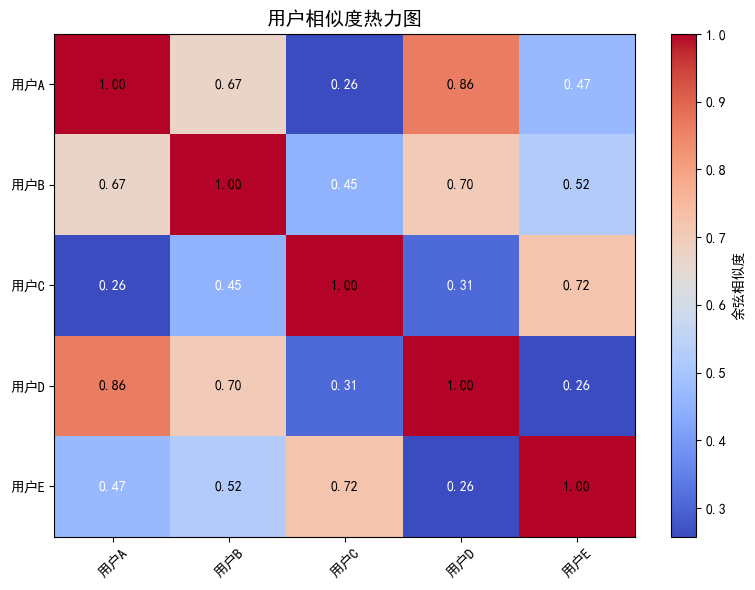


用户相似度矩阵：
        用户A     用户B     用户C     用户D     用户E
用户A  1.0000  0.6700  0.2593  0.8609  0.4686
用户B  0.6700  1.0000  0.4523  0.6989  0.5217
用户C  0.2593  0.4523  1.0000  0.3091  0.7210
用户D  0.8609  0.6989  0.3091  1.0000  0.2578
用户E  0.4686  0.5217  0.7210  0.2578  1.0000


In [15]:
# 计算用户相似度矩阵
user_sim_matrix = cosine_similarity(df.values)
user_sim_df = pd.DataFrame(user_sim_matrix, index=df.index, columns=df.index)

plt.figure(figsize=(8, 6))
plt.imshow(user_sim_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar(label='余弦相似度')
plt.xticks(range(len(df.index)), df.index, rotation=45)
plt.yticks(range(len(df.index)), df.index)
plt.title('用户相似度热力图', fontsize=14)

# 在格子里标注数值
for i in range(len(df.index)):
    for j in range(len(df.index)):
        plt.text(j, i, f'{user_sim_matrix[i, j]:.2f}', 
                ha='center', va='center', color='white' if user_sim_matrix[i, j] < 0.5 else 'black')

plt.tight_layout()
plt.show()

print("\n用户相似度矩阵：")
print(user_sim_df.round(4))

## 总结

### KNN 在推荐系统中的核心作用：

1. **相似度计算**：通过余弦相似度、皮尔逊相关系数等度量，量化用户或物品间的相似程度

2. **邻居选择**：K值的选择很关键：
   - K太小：易受噪声影响，推荐结果不稳定
   - K太大：包含不相似邻居，推荐精度下降
   - 通常 K 取值在 5-50 之间，需根据数据量调整

3. **预测生成**：基于邻居的加权评分预测目标用户对未交互物品的喜好

### 优缺点分析：

**优点**：
- 算法简单直观，易于解释
- 无需训练模型，随时可加入新数据
- 推荐结果有可解释性（"和你相似的用户都喜欢..."）

**缺点**：
- 数据稀疏时效果差（冷启动问题）
- 用户/物品数量大时计算复杂度高
- 无法捕捉用户兴趣的时效变化

### 实际应用：
- **User-Based CF**：适用于用户数量相对较少、物品数量大的场景（如小众社区）
- **Item-Based CF**：适用于物品数量相对稳定、用户行为变化快的场景（如电商"看了又看"）

现代推荐系统通常会将 KNN-based CF 与矩阵分解（Matrix Factorization）、深度学习等方法结合使用。